# Project 2
## Submitted by: Vikas Gautam, Jose, Saueav
## Date: 22/7/2025

In [1]:
# pip install pgmpy

In [2]:
# pip install hmmlearn

In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt
import warnings
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer
from pgmpy.estimators import HillClimbSearch, BIC
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator
import pandas_datareader.data as web
from sklearn.preprocessing import KBinsDiscretizer
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import BayesianEstimator,BIC , BDeu, HillClimbSearch
from pgmpy.inference import VariableElimination

import networkx as nx

import networkx as nx
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

## Step 1
## Forward and Back

In [4]:


# States and Observations
states = ['Rainy', 'Sunny']
observations = ['shop', 'clean', 'walk']
obs_map = {'shop': 0, 'clean': 1, 'walk': 2}
obs_seq = [obs_map[o] for o in observations]

# Parameters
pi = np.array([0.5, 0.5])  # Initial state probabilities
A = np.array([[0.7, 0.3],
              [0.4, 0.6]])  # Transition probabilities
B = np.array([[0.4, 0.5, 0.1],  # Emission probabilities for Rainy
              [0.3, 0.1, 0.6]])  # Emission probabilities for Sunny

T = len(obs_seq)
N = len(states)

### ----- FORWARD ALGORITHM ----- ###
alpha = np.zeros((T, N))
alpha[0] = pi * B[:, obs_seq[0]]

for t in range(1, T):
    for j in range(N):
        alpha[t, j] = B[j, obs_seq[t]] * np.sum(alpha[t - 1] * A[:, j])

p_forward = np.sum(alpha[-1])

### ----- BACKWARD ALGORITHM ----- ###
beta = np.zeros((T, N))
beta[T - 1] = 1

for t in reversed(range(T - 1)):
    for i in range(N):
        beta[t, i] = np.sum(A[i] * B[:, obs_seq[t + 1]] * beta[t + 1])

p_backward = np.sum(pi * B[:, obs_seq[0]] * beta[0])

### ----- OUTPUT RESULTS ----- ###
np.set_printoptions(precision=6, suppress=True)
print("Alpha Matrix (Forward Probabilities):\n", alpha)
print("\nBeta Matrix (Backward Probabilities):\n", beta)

print(f"\nP(O|λ) from Forward Algorithm:  {p_forward:.6f}")
print(f"P(O|λ) from Backward Algorithm: {p_backward:.6f}")

if np.isclose(p_forward, p_backward):
    print("\nThe probabilities match. Forward and Backward algorithms are consistent.")
else:
    print("\nThe probabilities DO NOT match. There may be an error.")


Alpha Matrix (Forward Probabilities):
 [[0.2    0.15  ]
 [0.1    0.015 ]
 [0.0076 0.0234]]

Beta Matrix (Backward Probabilities):
 [[0.0995 0.074 ]
 [0.25   0.4   ]
 [1.     1.    ]]

P(O|λ) from Forward Algorithm:  0.031000
P(O|λ) from Backward Algorithm: 0.031000

The probabilities match. Forward and Backward algorithms are consistent.


## Backward Viterbi algorithm

In [5]:


# States and Observations
states = ['Rainy', 'Sunny']
observations = ['walk', 'shop', 'clean']
obs_map = {'walk': 0, 'shop': 1, 'clean': 2}
obs_seq = [obs_map[o] for o in ['walk', 'shop', 'clean']]

# Parameters
pi = np.array([0.6, 0.4])  # Initial probabilities
A = np.array([[0.7, 0.3],
              [0.4, 0.6]])  # Transition matrix
B = np.array([[0.1, 0.4, 0.5],  # Rainy: walk, shop, clean
              [0.6, 0.3, 0.1]])  # Sunny: walk, shop, clean

T = len(obs_seq)
N = len(states)

# Initialization
delta = np.zeros((T, N))  # max probability of state path ending in state i
psi = np.zeros((T, N), dtype=int)  # backpointers

delta[0] = pi * B[:, obs_seq[0]]

# Forward recursion
for t in range(1, T):
    for j in range(N):
        prob = delta[t-1] * A[:, j]
        psi[t, j] = np.argmax(prob)
        delta[t, j] = np.max(prob) * B[j, obs_seq[t]]

# Termination
best_path_prob = np.max(delta[T-1])
last_state = np.argmax(delta[T-1])

# Backward path reconstruction
best_path = np.zeros(T, dtype=int)
best_path[T-1] = last_state

for t in range(T-2, -1, -1):
    best_path[t] = psi[t+1, best_path[t+1]]

# Convert indices to state names
best_state_sequence = [states[i] for i in best_path]

print("Delta Matrix (Max Probabilities):\n", delta)
print("\nPsi Matrix (Backpointers):\n", psi)
print(f"\nMost Probable State Sequence: {best_state_sequence}")
print(f"Probability of the Best Path: {best_path_prob:.6f}")


Delta Matrix (Max Probabilities):
 [[0.06     0.24    ]
 [0.0384   0.0432  ]
 [0.01344  0.002592]]

Psi Matrix (Backpointers):
 [[0 0]
 [1 1]
 [0 1]]

Most Probable State Sequence: ['Sunny', 'Rainy', 'Rainy']
Probability of the Best Path: 0.013440


## Baum-Welch Algorithm Implementation for a Toy Example


In [6]:
# Baum-Welch Algorithm Implementation for a Toy Example

# Observations and states
observations = ['shop', 'clean', 'walk']
obs_map = {'shop': 0, 'clean': 1, 'walk': 2}
obs_seq = [obs_map[o] for o in observations]

states = ['Rainy', 'Sunny']
n_states = len(states)
n_observations = len(obs_map)
T = len(obs_seq)

# Initial parameters
pi = np.array([0.5, 0.5])
A = np.array([[0.7, 0.3],
              [0.4, 0.6]])
B = np.array([[0.4, 0.5, 0.1],
              [0.3, 0.1, 0.6]])

n_iter = 10

for it in range(n_iter):
    # Forward pass
    alpha = np.zeros((T, n_states))
    alpha[0] = pi * B[:, obs_seq[0]]
    for t in range(1, T):
        for j in range(n_states):
            alpha[t, j] = B[j, obs_seq[t]] * np.sum(alpha[t-1] * A[:, j])

    # Backward pass
    beta = np.zeros((T, n_states))
    beta[T-1] = 1
    for t in reversed(range(T-1)):
        for i in range(n_states):
            beta[t, i] = np.sum(A[i] * B[:, obs_seq[t+1]] * beta[t+1])

    # Compute gamma and xi
    gamma = np.zeros((T, n_states))
    xi = np.zeros((T-1, n_states, n_states))

    for t in range(T):
        denom = np.sum(alpha[t] * beta[t])
        gamma[t] = (alpha[t] * beta[t]) / denom

    for t in range(T-1):
        denom = np.sum(alpha[t][:, None] * A * B[:, obs_seq[t+1]] * beta[t+1])
        for i in range(n_states):
            xi[t, i] = (alpha[t, i] * A[i] * B[:, obs_seq[t+1]] * beta[t+1]) / denom

    # Re-estimate pi, A, B
    pi = gamma[0]
    A = np.sum(xi, axis=0) / np.sum(gamma[:-1], axis=0)[:, None]

    for j in range(n_states):
        for k in range(n_observations):
            B[j, k] = sum(gamma[t, j] for t in range(T) if obs_seq[t] == k)
        B[j] /= np.sum(gamma[:, j])

    print(f"Iteration {it+1}:\nA =\n{A}\nB =\n{B}\npi = {pi}\n")


Iteration 1:
A =
[[0.545657 0.454343]
 [0.473684 0.526316]]
B =
[[0.379048 0.47619  0.144762]
 [0.274074 0.148148 0.577778]]
pi = [0.641935 0.358065]

Iteration 2:
A =
[[0.498437 0.501563]
 [0.475426 0.524574]]
B =
[[0.424533 0.44685  0.128617]
 [0.212117 0.182455 0.605428]]
pi = [0.726786 0.273214]

Iteration 3:
A =
[[0.463263 0.536737]
 [0.339468 0.660532]]
B =
[[0.492507 0.408074 0.09942 ]
 [0.121052 0.233656 0.645291]]
pi = [0.844382 0.155618]

Iteration 4:
A =
[[0.398909 0.601091]
 [0.104097 0.895903]]
B =
[[0.594064 0.34528  0.060656]
 [0.029781 0.319425 0.650794]]
pi = [0.958718 0.041282]

Iteration 5:
A =
[[0.266005 0.733995]
 [0.010959 0.989041]]
B =
[[0.733831 0.246567 0.019601]
 [0.001415 0.405242 0.593343]]
pi = [0.997679 0.002321]

Iteration 6:
A =
[[0.125837 0.874163]
 [0.000366 0.999634]]
B =
[[0.874108 0.124149 0.001743]
 [0.000003 0.462273 0.537724]]
pi = [0.999995 0.000005]

Iteration 7:
A =
[[0.031695 0.968305]
 [0.000001 0.999999]]
B =
[[0.968304 0.03168  0.000016]


## Step 2
## Bull Regime, Bear Regime and Stagnant Regime

In [7]:
# Download WTI crude oil prices
oil_data = yf.download('CL=F', start='2010-01-01', end='2025-01-01')
oil_data = oil_data[['Close']].dropna()
oil_data.rename(columns={'Close': 'Price'}, inplace=True)

# Compute log returns
oil_data['LogReturn'] = np.log(oil_data['Price'] / oil_data['Price'].shift(1))
oil_data.dropna(inplace=True)

# Fit 3-state Gaussian HMM
model = GaussianHMM(n_components=3, covariance_type="full", n_iter=10000)
model.fit(oil_data[['LogReturn']])
hidden_states = model.predict(oil_data[['LogReturn']])
oil_data['Regime'] = hidden_states

# Identify regimes
means = model.means_.flatten()
bull_state = np.argmax(means)
bear_state = np.argmin(means)
stagnant_state = list(set(range(3)) - {bull_state, bear_state})[0]

# Regime statistics
def regime_stats(data, state, name):
    regime_df = data[data['Regime'] == state]
    num_days = regime_df.shape[0]
    cumulative_return = np.exp(regime_df['LogReturn'].sum()) - 1
    avg_daily_return = regime_df['LogReturn'].mean()
    return {
        "Regime": name,
        "State ID": state,
        "Number of Days": num_days,
        "Average Daily Return": round(avg_daily_return, 5)
    }

stats = [
    regime_stats(oil_data, bull_state, "Bull"),
    regime_stats(oil_data, bear_state, "Bear"),
    regime_stats(oil_data, stagnant_state, "Stagnant")
]

regime_stats_df = pd.DataFrame(stats)
print("\n Regime Summary:")
print(regime_stats_df)


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed



 Regime Summary:
     Regime  State ID  Number of Days  Average Daily Return
0      Bull         1              89               0.00594
1      Bear         0            1346              -0.00165
2  Stagnant         2            2334               0.00093


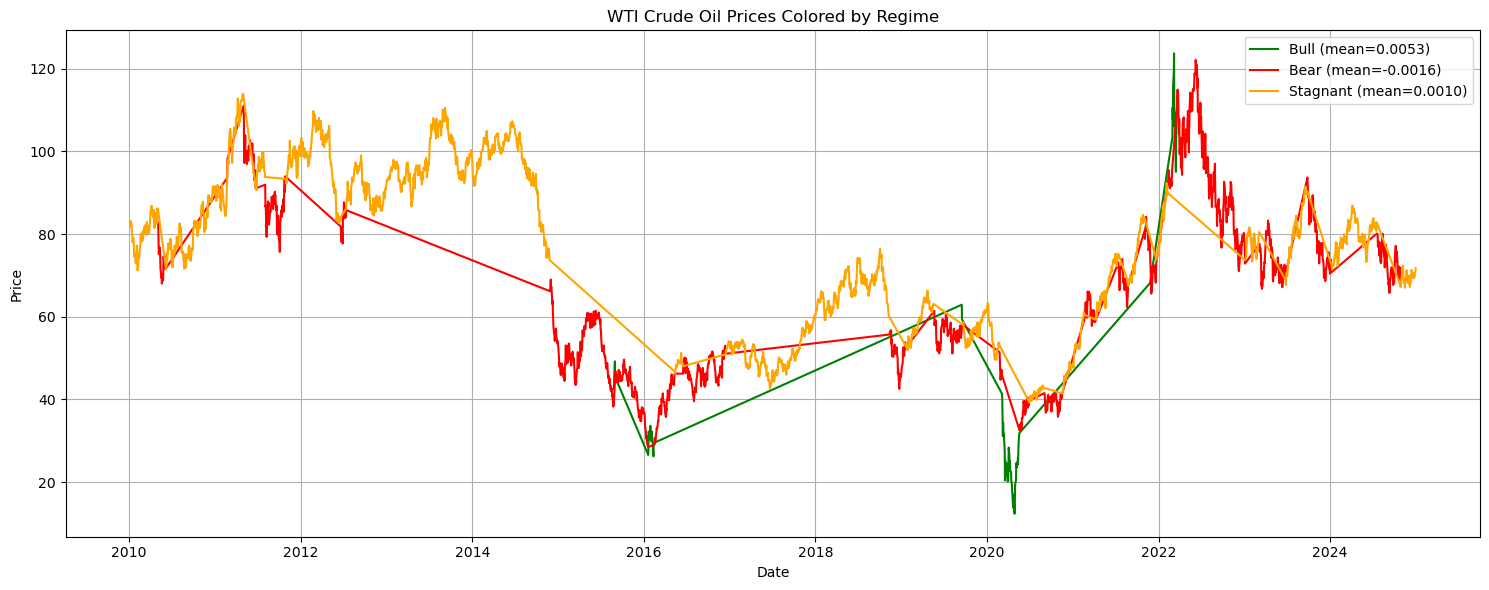

In [8]:
# Visualization
color_map = {
    bull_state: "green",
    bear_state: "red",
    stagnant_state: "orange"
}

label_map = {
    bull_state: f"Bull (mean={means[bull_state]:.4f})",
    bear_state: f"Bear (mean={means[bear_state]:.4f})",
    stagnant_state: f"Stagnant (mean={means[stagnant_state]:.4f})"
}

plt.figure(figsize=(15, 6))
for state in [bull_state, bear_state, stagnant_state]:
    mask = (oil_data['Regime'] == state)
    plt.plot(oil_data.index[mask], oil_data['Price'][mask],
             label=label_map[state], color=color_map[state])

plt.title("WTI Crude Oil Prices Colored by Regime")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Step 5

In [9]:
# 1. Download NASDAQ & macro data
import yfinance as yf

nasdaq = yf.download('^IXIC', start='2010-01-01', end='2025-01-01', progress=False)
nasdaq = nasdaq['Close']  # Extract price column
nasdaq = nasdaq.resample('M').last()  # Monthly data

log_returns = np.log(nasdaq / nasdaq.shift(1)).dropna()
log_returns.name="NASDAQ_Return"

gdp = web.DataReader('GDP', 'fred', '2010-01-01', '2025-01-01').resample('M').ffill()
cpi = web.DataReader('CPIAUCNS', 'fred', '2010-01-01', '2025-01-01').resample('M').ffill()
unemp = web.DataReader('UNRATE', 'fred', '2010-01-01', '2025-01-01').resample('M').ffill()
fedfunds = web.DataReader('FEDFUNDS', 'fred', '2010-01-01', '2025-01-01').resample('M').ffill()

# 2. Add WTI Crude Oil
oil_data = yf.download('CL=F', start='2010-01-01', end='2025-01-01', progress=False)
oil_data = oil_data[['Close']].dropna()
oil_data.rename(columns={'Close': 'WTI_Price'}, inplace=True)
oil_data['Oil_LogReturn'] = np.log(oil_data['WTI_Price'] / oil_data['WTI_Price'].shift(1))
oil_monthly = oil_data['Oil_LogReturn'].resample('M').mean().dropna()

# 3. Merge all data
data = pd.concat([log_returns, gdp, cpi, unemp, fedfunds, oil_monthly], axis=1)
data.columns = ['NASDAQ_Return', 'GDP', 'CPI', 'Unemployment', 'FedFunds', 'Oil_LogReturn']
data = data.dropna()

# 4. Discretize for Bayesian Network
disc = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')
disc_data = pd.DataFrame(disc.fit_transform(data), columns=data.columns, index=data.index)

# 5. Define BN structure manually
model = DiscreteBayesianNetwork([
    ('NASDAQ_Return', 'Oil_LogReturn'),
    ('FedFunds', 'NASDAQ_Return'),
    ('Unemployment', 'NASDAQ_Return'),
    ('Regime', 'NASDAQ_Return'),
    ('Regime', 'Unemployment'),
    ('Regime', 'GDP'),
    ('Regime', 'CPI'),
])

# Add a dummy Regime column for now (you can replace it later using HMM)
disc_data['Regime'] = np.random.choice([0, 1, 2], size=len(disc_data))

# -----------------------
# 6. Fit the model with parameters
# -----------------------
model.fit(disc_data, estimator=BayesianEstimator, prior_type='BDeu')

# -----------------------
# 7. Inference example
# -----------------------
inference = VariableElimination(model)
result = inference.query(variables=['Oil_LogReturn'], evidence={'Regime': 1})  # Bear regime
print("\n🔍 Inference result: P(Oil_LogReturn | Regime = 1):\n", result)



INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'NASDAQ_Return': 'N', 'GDP': 'N', 'CPI': 'N', 'Unemployment': 'N', 'FedFunds': 'N', 'Oil_LogReturn': 'N', 'Regime': 'N'}



🔍 Inference result: P(Oil_LogReturn | Regime = 1):
 +--------------------+----------------------+
| Oil_LogReturn      |   phi(Oil_LogReturn) |
+====================+======================+
| Oil_LogReturn(0.0) |               0.3577 |
+--------------------+----------------------+
| Oil_LogReturn(1.0) |               0.3254 |
+--------------------+----------------------+
| Oil_LogReturn(2.0) |               0.3168 |
+--------------------+----------------------+


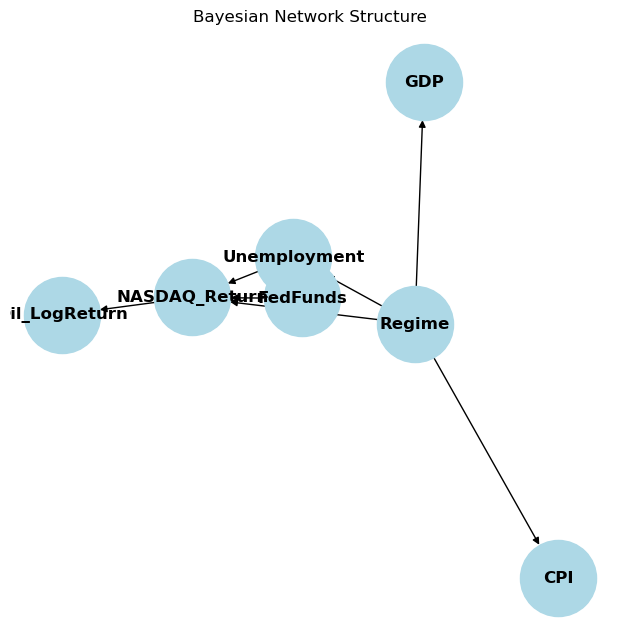

In [10]:

# Create a directed graph from the pgmpy model's edges
G = nx.DiGraph()
G.add_edges_from(model.edges())

# Plot
plt.figure(figsize=(6, 6))
nx.draw(G, with_labels=True, node_color='lightblue', node_size=3000, font_size=12, font_weight='bold')
plt.title("Bayesian Network Structure")
plt.show()


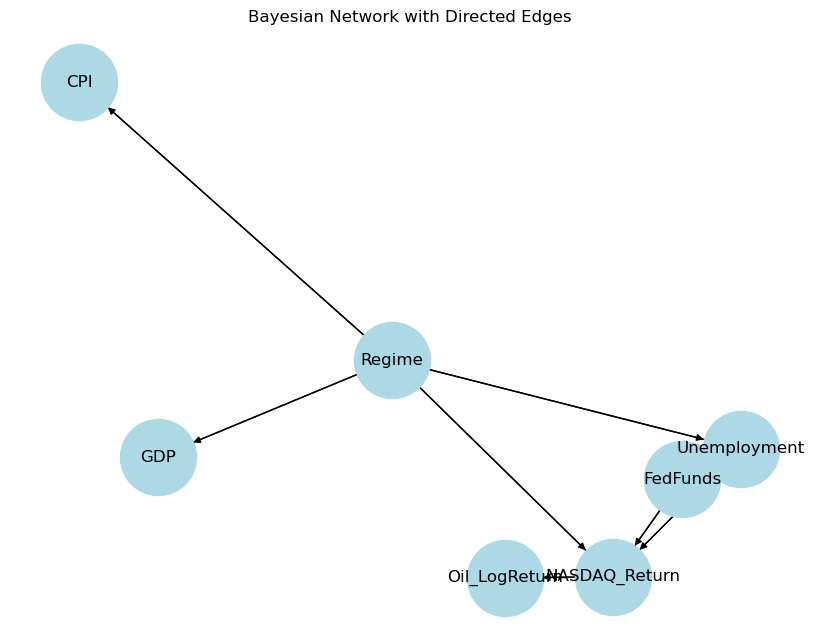

In [11]:
pos = nx.spring_layout(G)
plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=3000, arrows=True)
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20)
plt.title("Bayesian Network with Directed Edges")
plt.show()


## Step 9
## HillClimb Search

In [12]:

disc_data = data.copy()
est = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='quantile')  # 3 states: low, medium, high
disc_data[:] = est.fit_transform(disc_data)
disc_data = disc_data.astype(int)


In [13]:

hc = HillClimbSearch(disc_data)
best_model = hc.estimate(scoring_method=BIC(disc_data))

# Convert to Bayesian model
model = DiscreteBayesianNetwork(best_model.edges())


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'NASDAQ_Return': 'N', 'GDP': 'N', 'CPI': 'N', 'Unemployment': 'N', 'FedFunds': 'N', 'Oil_LogReturn': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'NASDAQ_Return': 'N', 'GDP': 'N', 'CPI': 'N', 'Unemployment': 'N', 'FedFunds': 'N', 'Oil_LogReturn': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'NASDAQ_Return': 'N', 'GDP': 'N', 'CPI': 'N', 'Unemployment': 'N', 'FedFunds': 'N', 'Oil_LogReturn': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

In [14]:

model.fit(disc_data, estimator=BayesianEstimator, prior_type="BDeu")


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'NASDAQ_Return': 'N', 'GDP': 'N', 'CPI': 'N', 'Unemployment': 'N', 'FedFunds': 'N', 'Oil_LogReturn': 'N'}


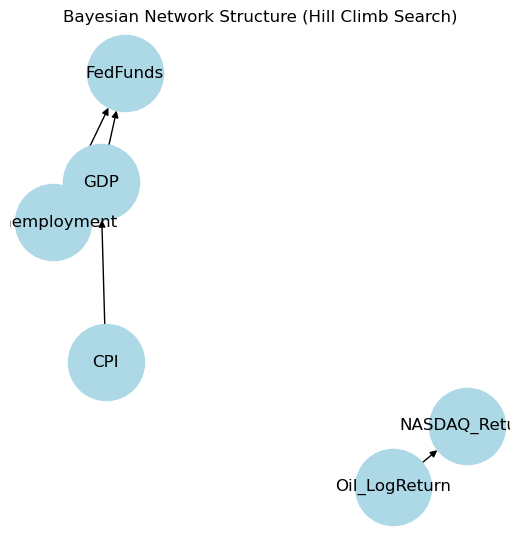

In [15]:


G = nx.DiGraph()
G.add_edges_from(model.edges())

plt.figure(figsize=(5, 5))
nx.draw(G, with_labels=True, node_color='lightblue', node_size=3000, font_size=12, arrows=True)
plt.title("Bayesian Network Structure (Hill Climb Search)")
plt.show()
